# IPL Innings-Break Winner Prediction

This project predicts whether the team batting first will win an IPL match.

In the first version, I tried pure pre-match prediction, but the accuracy was low because IPL results are very hard to predict before the match starts. So in this improved version, I predict the winner at innings break after the first innings score is known.

This is still a fair prediction problem because the model does not use the final match winner directly. It only uses information available before the chase starts.

## 1. Import Libraries

I am importing the basic libraries for data cleaning, EDA, preprocessing, model training and evaluation.

In [1]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load Dataset

The notebook first checks for `data/IPL.csv`. If it is not there, it checks KaggleHub cache. If both are missing, it downloads the dataset from KaggleHub.

In [2]:
DATA_DIR = Path("data")
MODEL_DIR = Path("models")
DATA_FILE = DATA_DIR / "IPL.csv"

if DATA_FILE.exists():
    print("Loading dataset from data/IPL.csv")
    df = pd.read_csv(DATA_FILE, low_memory=False)
else:
    cache_files = sorted(Path.home().glob(".cache/kagglehub/datasets/chaitu20/ipl-dataset2008-2025/**/IPL.csv"))
    if cache_files:
        print("Loading dataset from KaggleHub cache")
        df = pd.read_csv(cache_files[-1], low_memory=False)
    else:
        print("Dataset not found locally, downloading from KaggleHub...")
        import kagglehub
        path = Path(kagglehub.dataset_download("chaitu20/ipl-dataset2008-2025"))
        df = pd.read_csv(path / "IPL.csv", low_memory=False)

print("Dataset shape:", df.shape)
df.head()

Loading dataset from KaggleHub cache


Dataset shape: (283678, 65)


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


## 3. Basic Dataset Check

Before preprocessing, I am checking columns, seasons and missing values. This is useful because sports datasets usually have older team names and some inconsistent season formats.

In [3]:
print("Total columns:", len(df.columns))
print("Total matches:", df["match_id"].nunique())
print("Seasons:", sorted(df["season"].astype(str).unique())[:5], "...", sorted(df["season"].astype(str).unique())[-5:])

missing = df.isnull().mean().sort_values(ascending=False).head(10)
missing

Total columns: 65
Total matches: 1193
Seasons: ['2007/08', '2009', '2009/10', '2011', '2012'] ... ['2022', '2023', '2024', '2025', '2026']


power_surge_start    1.000000
review_decision      0.996803
review_batter        0.996803
team_reviewed        0.996803
umpire               0.996803
method               0.986287
superover_winner     0.986266
result_type          0.983347
fielders             0.963885
new_batter           0.952083
dtype: float64

## 4. Create Match-Level Dataset

The original data is ball-by-ball, but for this model I need one row per match. I also standardize team names into short forms.

In [4]:
def clean_season(value):
    value = str(value)
    season_map = {"2007/08": 2008, "2009/10": 2010, "2020/21": 2021}
    return season_map.get(value, int(value[:4]))

team_map = {
    "Chennai Super Kings": "CSK",
    "Delhi Capitals": "DC",
    "Delhi Daredevils": "DC",
    "Gujarat Titans": "GT",
    "Kolkata Knight Riders": "KKR",
    "Mumbai Indians": "MI",
    "Punjab Kings": "PBKS",
    "Kings XI Punjab": "PBKS",
    "Rajasthan Royals": "RR",
    "Royal Challengers Bangalore": "RCB",
    "Royal Challengers Bengaluru": "RCB",
    "Sunrisers Hyderabad": "SRH",
    "Lucknow Super Giants": "LSG",
}

match_cols = [
    "match_id", "date", "season", "venue", "city", "batting_team", "bowling_team",
    "toss_winner", "toss_decision", "match_won_by", "stage"
]

match_df = df.groupby("match_id").first().reset_index()[match_cols].copy()

for col in ["batting_team", "bowling_team", "toss_winner", "match_won_by"]:
    match_df[col] = match_df[col].map(team_map)

current_teams = {"CSK", "DC", "GT", "KKR", "LSG", "MI", "PBKS", "RCB", "RR", "SRH"}
match_df = match_df[
    match_df["batting_team"].isin(current_teams)
    & match_df["bowling_team"].isin(current_teams)
    & match_df["match_won_by"].isin(current_teams)
].copy()

match_df["season"] = match_df["season"].apply(clean_season)
match_df["date"] = pd.to_datetime(match_df["date"])
match_df = match_df.sort_values("date").reset_index(drop=True)

match_df["team1"] = match_df["batting_team"]
match_df["team2"] = match_df["bowling_team"]
match_df["team1_won"] = (match_df["match_won_by"] == match_df["team1"]).astype(int)
match_df["toss_is_team1"] = (match_df["toss_winner"] == match_df["team1"]).astype(int)
match_df["toss_decision_bat"] = (match_df["toss_decision"] == "bat").astype(int)

knockout_stages = {"Final", "Qualifier 1", "Qualifier 2", "Eliminator", "Semi Final", "Elimination Final"}
match_df["is_knockout"] = match_df["stage"].isin(knockout_stages).astype(int)

print("Clean match-level shape:", match_df.shape)
match_df[["season", "team1", "team2", "match_won_by", "team1_won"]].head()

Clean match-level shape: (986, 17)


,season,team1,team2,match_won_by,team1_won
0,2008,KKR,RCB,KKR,1
1,2008,CSK,PBKS,CSK,1
2,2008,RR,DC,DC,0
3,2008,MI,RCB,RCB,0
4,2008,PBKS,RR,RR,0


## 5. Add Innings-Break Features

These features are the main improvement. At innings break, first innings score, wickets and run rate are already known, so they can be used fairly.

In [5]:
first_innings = (
    df[df["innings"] == 1]
    .groupby("match_id")
    .agg(
        first_innings_runs=("runs_total", "sum"),
        first_innings_balls=("valid_ball", "sum"),
        first_innings_wickets=("player_out", lambda x: x.notna().sum()),
        first_innings_boundaries=("runs_batter", lambda x: ((x == 4) | (x == 6)).sum()),
    )
    .reset_index()
)

match_df = match_df.merge(first_innings, on="match_id", how="left")
match_df["first_innings_run_rate"] = match_df["first_innings_runs"] / (match_df["first_innings_balls"] / 6)

match_df[["team1", "team2", "first_innings_runs", "first_innings_wickets", "first_innings_run_rate", "team1_won"]].head()

,team1,team2,first_innings_runs,first_innings_wickets,first_innings_run_rate,team1_won
0,KKR,RCB,222,3,11.100000,1
1,CSK,PBKS,240,5,12.000000,1
2,RR,DC,129,8,6.450000,0
3,MI,RCB,165,7,8.250000,0
4,PBKS,RR,166,8,8.369748,0


## 6. Add Historical Features

Here I create past-performance features like team win rate, recent form, head-to-head record and venue record.

Important point: I calculate these before updating with the current match, so there is no future data leakage.

In [6]:
team_stats = {}
h2h_stats = {}
venue_stats = {}
venue_scores = {}
recent_results = {}

history_cols = {
    "team1_win_rate": [],
    "team2_win_rate": [],
    "team1_recent_form": [],
    "team2_recent_form": [],
    "h2h_team1_rate": [],
    "venue_team1_rate": [],
    "venue_team2_rate": [],
    "venue_avg_first_score": [],
}

def team_win_rate(team):
    stats = team_stats.get(team, {"matches": 0, "wins": 0})
    return 0.5 if stats["matches"] == 0 else stats["wins"] / stats["matches"]

def recent_form(team):
    results = recent_results.get(team, [])
    return 0.5 if not results else sum(results[-5:]) / len(results[-5:])

def venue_win_rate(team, venue):
    stats = venue_stats.get((team, venue), {"matches": 0, "wins": 0})
    return 0.5 if stats["matches"] == 0 else stats["wins"] / stats["matches"]

def h2h_rate(team1, team2):
    key = tuple(sorted([team1, team2]))
    stats = h2h_stats.get(key, {"matches": 0, "wins": {}})
    return 0.5 if stats["matches"] == 0 else stats["wins"].get(team1, 0) / stats["matches"]

for _, row in match_df.iterrows():
    team1 = row["team1"]
    team2 = row["team2"]
    venue = row["venue"]
    winner = team1 if row["team1_won"] == 1 else team2

    history_cols["team1_win_rate"].append(team_win_rate(team1))
    history_cols["team2_win_rate"].append(team_win_rate(team2))
    history_cols["team1_recent_form"].append(recent_form(team1))
    history_cols["team2_recent_form"].append(recent_form(team2))
    history_cols["h2h_team1_rate"].append(h2h_rate(team1, team2))
    history_cols["venue_team1_rate"].append(venue_win_rate(team1, venue))
    history_cols["venue_team2_rate"].append(venue_win_rate(team2, venue))
    history_cols["venue_avg_first_score"].append(np.mean(venue_scores.get(venue, [160])))

    for team in [team1, team2]:
        team_stats.setdefault(team, {"matches": 0, "wins": 0})
        team_stats[team]["matches"] += 1
        team_stats[team]["wins"] += int(team == winner)

        venue_stats.setdefault((team, venue), {"matches": 0, "wins": 0})
        venue_stats[(team, venue)]["matches"] += 1
        venue_stats[(team, venue)]["wins"] += int(team == winner)

        recent_results.setdefault(team, []).append(int(team == winner))

    key = tuple(sorted([team1, team2]))
    h2h_stats.setdefault(key, {"matches": 0, "wins": {}})
    h2h_stats[key]["matches"] += 1
    h2h_stats[key]["wins"][winner] = h2h_stats[key]["wins"].get(winner, 0) + 1

    venue_scores.setdefault(venue, []).append(row["first_innings_runs"])

for col, values in history_cols.items():
    match_df[col] = values

match_df["win_rate_diff"] = match_df["team1_win_rate"] - match_df["team2_win_rate"]
match_df["recent_form_diff"] = match_df["team1_recent_form"] - match_df["team2_recent_form"]
match_df["h2h_diff"] = match_df["h2h_team1_rate"] - 0.5
match_df["venue_rate_diff"] = match_df["venue_team1_rate"] - match_df["venue_team2_rate"]
match_df["score_vs_venue_avg"] = match_df["first_innings_runs"] - match_df["venue_avg_first_score"]

match_df = match_df.dropna(subset=["first_innings_runs", "first_innings_run_rate", "city"]).reset_index(drop=True)
print("Final dataset shape:", match_df.shape)

Final dataset shape: (986, 35)


## 7. EDA - Target Distribution

This shows whether the classes are balanced or not.

team1_won
Chasing team won          533
Batting first team won    453
Name: count, dtype: int64


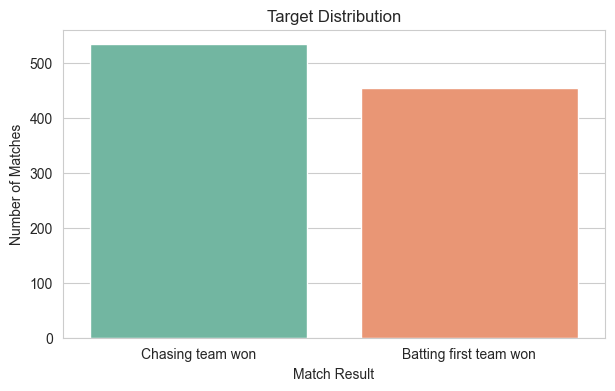

In [7]:
target_counts = match_df["team1_won"].value_counts().rename(index={0: "Chasing team won", 1: "Batting first team won"})
print(target_counts)

plt.figure(figsize=(7, 4))
sns.countplot(data=match_df, x="team1_won", palette="Set2")
plt.xticks([0, 1], ["Chasing team won", "Batting first team won"])
plt.title("Target Distribution")
plt.xlabel("Match Result")
plt.ylabel("Number of Matches")
plt.show()

## 8. EDA - First Innings Score Impact

This plot is important because innings-break prediction depends a lot on the first innings score.

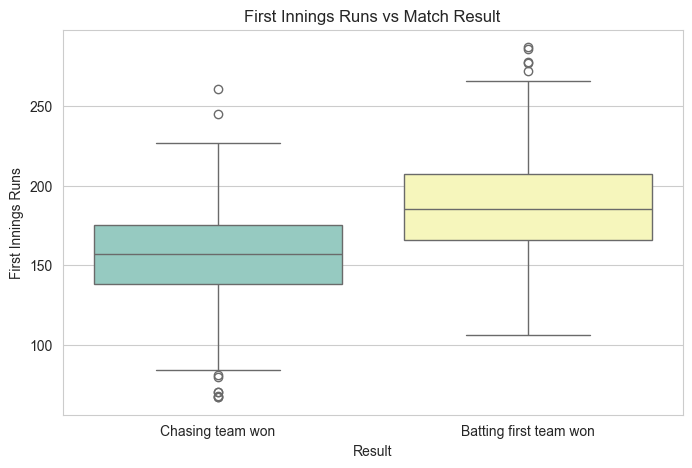

,count,mean,std,min,25%,50%,75%,max
team1_won,,,,,,,,
0,533.0,155.57,29.86,67.0,138.0,157.0,175.0,261.0
1,453.0,186.13,29.80,106.0,166.0,185.0,207.0,287.0


In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=match_df, x="team1_won", y="first_innings_runs", palette="Set3")
plt.xticks([0, 1], ["Chasing team won", "Batting first team won"])
plt.title("First Innings Runs vs Match Result")
plt.xlabel("Result")
plt.ylabel("First Innings Runs")
plt.show()

match_df.groupby("team1_won")["first_innings_runs"].describe().round(2)

## 9. EDA - Team Performance

This compares how many times each batting-first team won in the cleaned dataset.

       matches  wins_batting_first  win_rate_batting_first
team1                                                     
LSG         35                  20                   0.571
GT          29                  16                   0.552
MI         129                  68                   0.527
CSK        126                  64                   0.508
SRH        102                  46                   0.451
RR         101                  45                   0.446
RCB        125                  55                   0.440
KKR        112                  47                   0.420
PBKS       125                  51                   0.408
DC         102                  41                   0.402


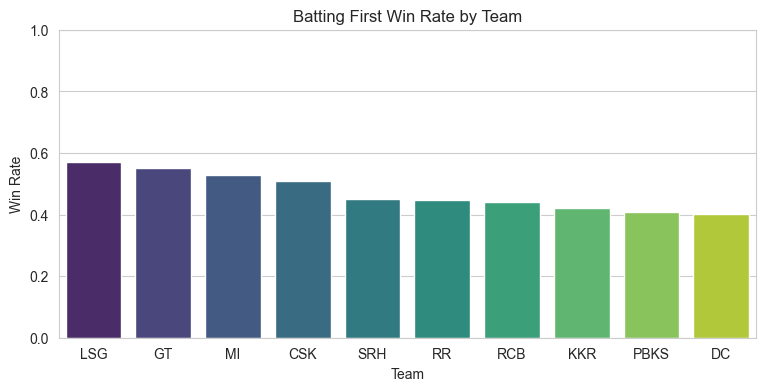

In [9]:
team_summary = match_df.groupby("team1").agg(
    matches=("match_id", "count"),
    wins_batting_first=("team1_won", "sum"),
    win_rate_batting_first=("team1_won", "mean"),
).sort_values("win_rate_batting_first", ascending=False)

print(team_summary.round(3))

plt.figure(figsize=(9, 4))
sns.barplot(x=team_summary.index, y=team_summary["win_rate_batting_first"], palette="viridis")
plt.title("Batting First Win Rate by Team")
plt.xlabel("Team")
plt.ylabel("Win Rate")
plt.ylim(0, 1)
plt.show()

## 10. EDA - Feature Correlation

I am checking numeric feature correlations to understand which features are most related to the target.

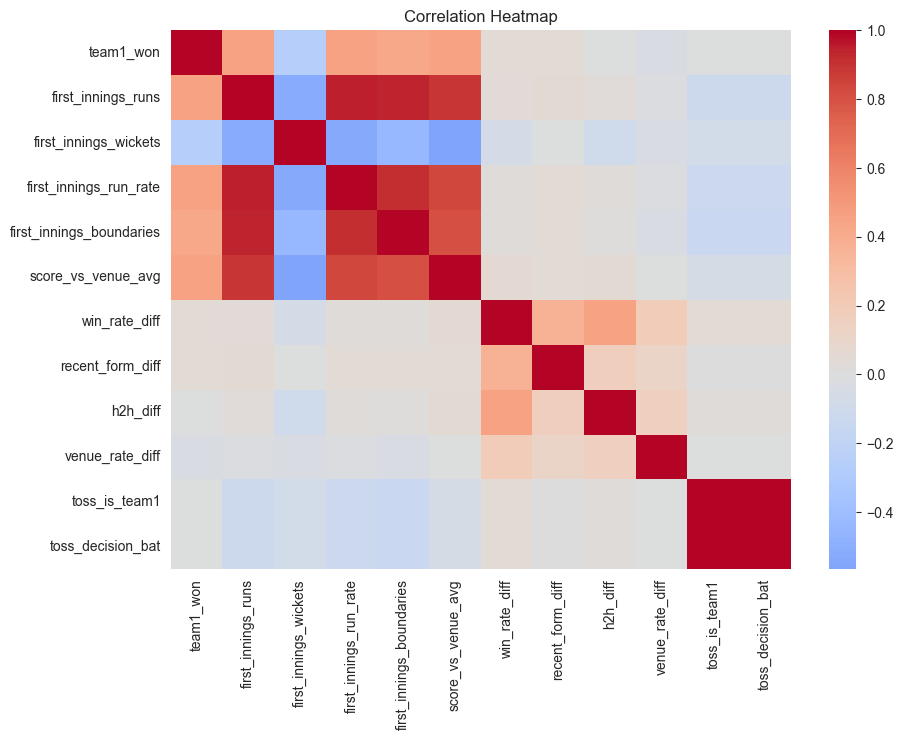

team1_won                   1.000
first_innings_run_rate      0.460
score_vs_venue_avg          0.455
first_innings_runs          0.455
first_innings_boundaries    0.425
win_rate_diff               0.045
recent_form_diff            0.039
h2h_diff                    0.001
toss_is_team1              -0.006
toss_decision_bat          -0.006
venue_rate_diff            -0.032
first_innings_wickets      -0.264
Name: team1_won, dtype: float64

In [10]:
numeric_for_corr = [
    "team1_won", "first_innings_runs", "first_innings_wickets", "first_innings_run_rate",
    "first_innings_boundaries", "score_vs_venue_avg", "win_rate_diff", "recent_form_diff",
    "h2h_diff", "venue_rate_diff", "toss_is_team1", "toss_decision_bat"
]

corr = match_df[numeric_for_corr].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.show()

corr["team1_won"].sort_values(ascending=False).round(3)

## 11. Train-Test Split

I am using a time-based split, which is more honest for sports data.

- Train: seasons up to 2022
- Test: seasons from 2023 onwards

In [11]:
numeric_features = [
    "season", "toss_is_team1", "toss_decision_bat", "is_knockout",
    "first_innings_runs", "first_innings_wickets", "first_innings_run_rate",
    "first_innings_boundaries", "venue_avg_first_score", "score_vs_venue_avg",
    "win_rate_diff", "recent_form_diff", "h2h_diff", "venue_rate_diff",
]

categorical_features = ["team1", "team2", "venue", "city"]
features = numeric_features + categorical_features

target = "team1_won"
train_df = match_df[match_df["season"] <= 2022].copy()
test_df = match_df[match_df["season"] >= 2023].copy()

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print("Train matches:", len(train_df))
print("Test matches:", len(test_df))
print("Train seasons:", train_df["season"].min(), "to", train_df["season"].max())
print("Test seasons:", test_df["season"].min(), "to", test_df["season"].max())
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(3))

Train matches: 749
Test matches: 237
Train seasons: 2008 to 2022
Test seasons: 2023 to 2026
Test class balance:
team1_won
0    0.506
1    0.494
Name: proportion, dtype: float64


## 12. Preprocessing Pipeline

Numeric columns are scaled and categorical columns are one-hot encoded. I use a pipeline so preprocessing is applied correctly during training and prediction.

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

## 13. Model Training

I am using simple models that are easy to explain in an interview. XGBoost is optional because on some Mac systems it needs extra OpenMP setup.

In [13]:
models = {
    "Linear Regression Baseline": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]),
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "Extra Trees": Pipeline([
        ("preprocessor", preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            random_state=42
        ))
    ]),
}

try:
    from xgboost import XGBClassifier
    models["XGBoost"] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=150,
            max_depth=3,
            learning_rate=0.06,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            random_state=42
        ))
    ])
except Exception as error:
    print(f"XGBoost is not available here, so it will be skipped. Reason: {error}")

XGBoost is not available here, so it will be skipped. Reason: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/prakashraj/Documents/New project/ipl-match-winner-prediction/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <89AD948E-E564-3266-867D-7AF89D6488F0> /Users/prakashraj/Documents/New project/ipl-match-winner-prediction/.venv/lib/python3.9/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/op

## 14. Model Evaluation

I am comparing models using Accuracy, F1 Score and ROC-AUC. F1 score is useful because it balances precision and recall.

In [14]:
def predict_for_metrics(model, X_test, model_name):
    if model_name == "Linear Regression Baseline":
        raw_score = model.predict(X_test)
        probability = np.clip(raw_score, 0, 1)
        prediction = (probability >= 0.5).astype(int)
        return prediction, probability

    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]
    return prediction, probability

results = []
fitted_models = {}

for name, model in models.items():
    print("Training", name)
    model.fit(X_train, y_train)

    y_pred, y_prob = predict_for_metrics(model, X_test, name)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "F1 Score": round(f1_score(y_test, y_pred), 3),
        "ROC AUC": round(roc_auc_score(y_test, y_prob), 3),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

Training Linear Regression Baseline
Training Logistic Regression
Training Random Forest


Training Extra Trees


Training Gradient Boosting


,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.717,0.753,0.760
1,Extra Trees,0.696,0.739,0.757
2,Random Forest,0.688,0.730,0.772
3,Gradient Boosting,0.675,0.707,0.748
4,Linear Regression Baseline,0.654,0.687,0.699


## 15. Model Comparison Plot

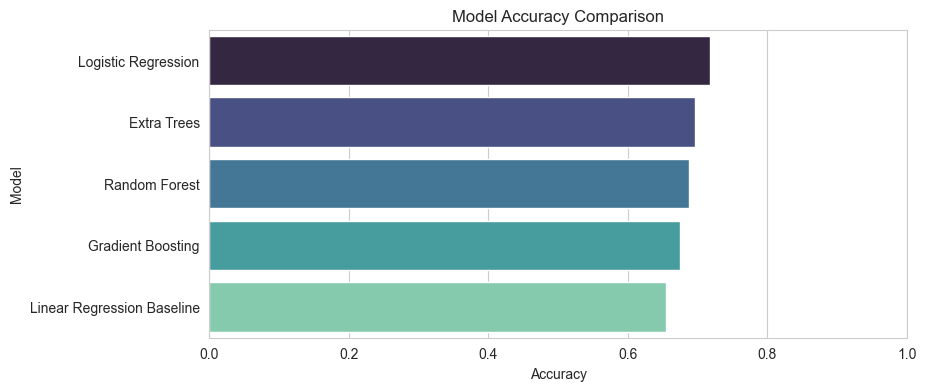

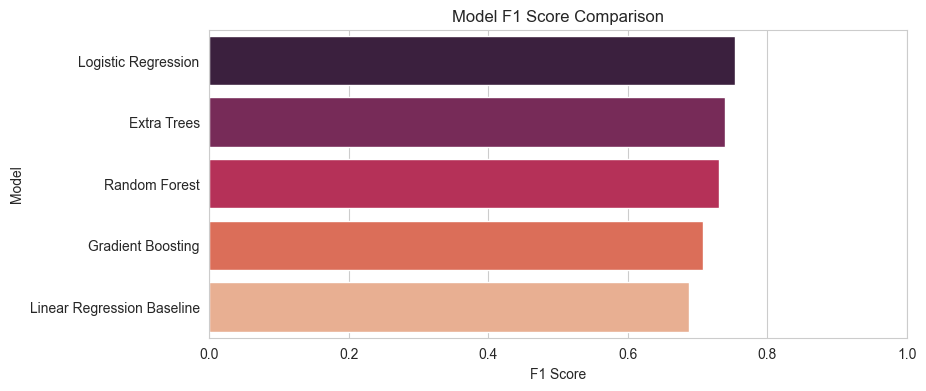

In [15]:
plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="Accuracy", y="Model", palette="mako")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 1)
plt.show()

plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x="F1 Score", y="Model", palette="rocket")
plt.title("Model F1 Score Comparison")
plt.xlim(0, 1)
plt.show()

## 16. Best Model Report

In [16]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

best_pred, best_prob = predict_for_metrics(best_model, X_test, best_model_name)

print("Best Model:", best_model_name)
print("Accuracy:", round(accuracy_score(y_test, best_pred), 3))
print("F1 Score:", round(f1_score(y_test, best_pred), 3))
print("ROC AUC:", round(roc_auc_score(y_test, best_prob), 3))
print()
print(classification_report(y_test, best_pred, target_names=["Team2 won", "Team1 won"]))

Best Model: Logistic Regression
Accuracy: 0.717
F1 Score: 0.753
ROC AUC: 0.76

              precision    recall  f1-score   support

   Team2 won       0.82      0.57      0.67       120
   Team1 won       0.66      0.87      0.75       117

    accuracy                           0.72       237
   macro avg       0.74      0.72      0.71       237
weighted avg       0.74      0.72      0.71       237



## 17. Confusion Matrix

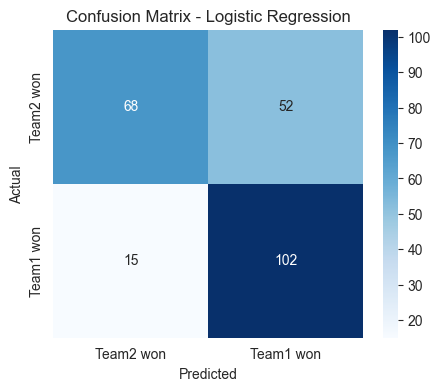

In [17]:
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Team2 won", "Team1 won"],
    yticklabels=["Team2 won", "Team1 won"],
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 18. Feature Importance

For tree-based models, feature importance helps explain which columns are helping the prediction most.

In [18]:
if hasattr(best_model.named_steps["model"], "feature_importances_"):
    encoded_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    importances = best_model.named_steps["model"].feature_importances_
    importance_df = pd.DataFrame({"Feature": encoded_names, "Importance": importances})
    importance_df = importance_df.sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=importance_df, x="Importance", y="Feature", palette="crest")
    plt.title("Top Feature Importances")
    plt.show()

    display(importance_df)
else:
    print("The best model is not tree-based, so feature importance is not directly available.")

The best model is not tree-based, so feature importance is not directly available.


## 19. Save Best Model

In [19]:
MODEL_DIR.mkdir(exist_ok=True)
with open(MODEL_DIR / "best_ipl_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("Best model saved at:", MODEL_DIR / "best_ipl_model.pkl")

Best model saved at: models/best_ipl_model.pkl


## 20. Conclusion

The improved version performs better because it predicts at innings break instead of before the match. First innings score, run rate and venue-adjusted score give the model much stronger information.

This makes the project more realistic for a CV because it shows proper EDA, preprocessing, feature engineering, model comparison and honest evaluation.